In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


from src.data_wrangling_pipeline import build_unified_dataset, quality_report

pd.set_option('display.max_columns', 200)
sns.set_theme(style='whitegrid')

import warnings
warnings.filterwarnings(action='ignore')

# Data Understanding

In [2]:
import pandas as pd
input = ROOT / 'data' / 'csv' / 'preprocessed' / 'final_listings_preprocessed.csv'
df = pd.read_csv(input)

In [3]:
df.head()

,record_id,description,transaction_type,property_type,price_tnd,surface_m2,price_per_m2,rooms,bedrooms,bathrooms,governorate,city,location_raw,latitude,longitude
0,9c60a3844240e0476b9e9c365831fa62bee23544,"Appartement disponible à L Aouina, Tunis. Pièc...",rent,Appartement,100.0,61.0,1.639344,1.0,0.0,1.0,Tunis,L Aouina,100,36.849148,10.263936
1,3f12e7da1a00d5c89572aa7bc36fd7b3f52757ea,"Appartement disponible à Sousse, Sousse. Pièce...",rent,Appartement,550.0,355.2,1.548423,2.0,2.0,1.0,Sousse,Sousse,550,35.828828,10.640525
2,a46cd5257139d149e7159d1543df8b7cd1f1c9e5,"Appartement à louer à Menzah, Tunis. Pièces: 1...",rent,Appartement,80.0,88.4,0.904977,1.0,0.0,1.0,Tunis,Menzah,80,36.839843,10.185176
3,c0728ca3ec92f88f033fd3762a20ebfbb75be96c,"Appartement à louer à Les Jardins El Menzah 2,...",rent,Appartement,999999.0,116.8,8561.635274,1.0,1.0,1.0,Ariana,Les Jardins El Menzah 2,999,34.614668,9.971303
4,44fa18bd14d385898a8bc7c7d415935c9636f4f0,"Appartement à louer à Hammam Lif, Ben Arous. P...",rent,Appartement,850.0,88.6,9.593679,2.0,2.0,1.0,Ben Arous,Hammam Lif,850,36.731379,10.336398


In [4]:
df.columns

Index(['record_id', 'description', 'transaction_type', 'property_type',
       'price_tnd', 'surface_m2', 'price_per_m2', 'rooms', 'bedrooms',
       'bathrooms', 'governorate', 'city', 'location_raw', 'latitude',
       'longitude'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10055 entries, 0 to 10054
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   record_id         10055 non-null  object 
 1   description       10055 non-null  object 
 2   transaction_type  10055 non-null  object 
 3   property_type     10055 non-null  object 
 4   price_tnd         10055 non-null  float64
 5   surface_m2        10055 non-null  float64
 6   price_per_m2      10055 non-null  float64
 7   rooms             10055 non-null  float64
 8   bedrooms          10055 non-null  float64
 9   bathrooms         10055 non-null  float64
 10  governorate       10055 non-null  object 
 11  city              10055 non-null  object 
 12  location_raw      10055 non-null  object 
 13  latitude          10055 non-null  float64
 14  longitude         10055 non-null  float64
dtypes: float64(8), object(7)
memory usage: 1.2+ MB


In [6]:
df.shape

(10055, 15)

In [7]:
df[['price_tnd','surface_m2','price_per_m2','rooms','bedrooms','bathrooms']].describe().T

,count,mean,std,min,25%,50%,75%,max
price_tnd,10055.0,1.458623e+06,1.141062e+07,50.000000,1200.00000,145000.000000,340000.0,2.360000e+08
surface_m2,10055.0,2.044937e+02,2.289294e+02,19.000000,89.00000,130.000000,220.0,2.778000e+03
price_per_m2,10055.0,1.250994e+04,1.073585e+05,0.046591,10.37903,909.090909,2150.0,2.565217e+06
rooms,10055.0,2.088314e+00,8.690680e-01,1.000000,1.00000,2.000000,3.0,6.000000e+00
bedrooms,10055.0,2.421283e+00,1.464501e+00,0.000000,1.00000,2.000000,3.0,1.000000e+01
bathrooms,10055.0,1.300945e+00,7.343176e-01,0.000000,1.00000,1.000000,1.0,1.000000e+01


In [8]:
df.isna().sum()

record_id           0
description         0
transaction_type    0
property_type       0
price_tnd           0
surface_m2          0
price_per_m2        0
rooms               0
bedrooms            0
bathrooms           0
governorate         0
city                0
location_raw        0
latitude            0
longitude           0
dtype: int64

In [9]:
print(f'Number of duplicates  is : {df.duplicated().sum()}')

Number of duplicates  is : 0


# EDA

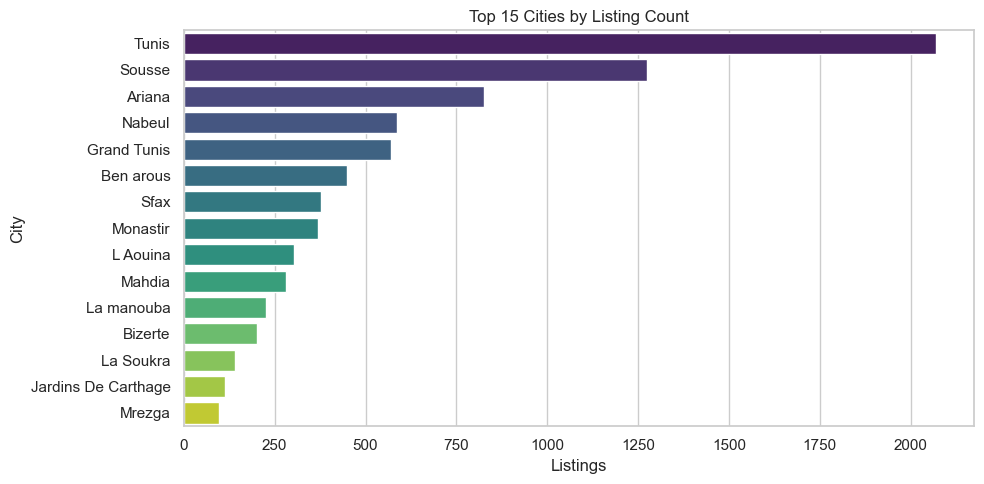

In [10]:
top_cities = df['city'].fillna('Unknown').value_counts().head(15)
plt.figure(figsize=(10,5))
sns.barplot(x=top_cities.values, y=top_cities.index, palette='viridis')
plt.title('Top 15 Cities by Listing Count')
plt.xlabel('Listings')
plt.ylabel('City')
plt.tight_layout()
plt.show()

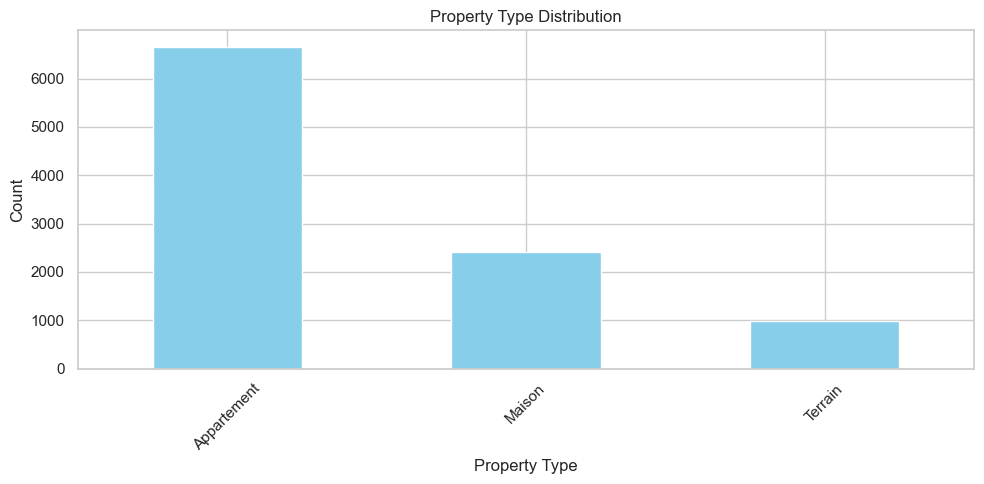

In [11]:
df['property_type'].fillna('Unknown').value_counts().plot(kind='bar', figsize=(10,5), color='skyblue')
plt.title('Property Type Distribution')
plt.xlabel('Property Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

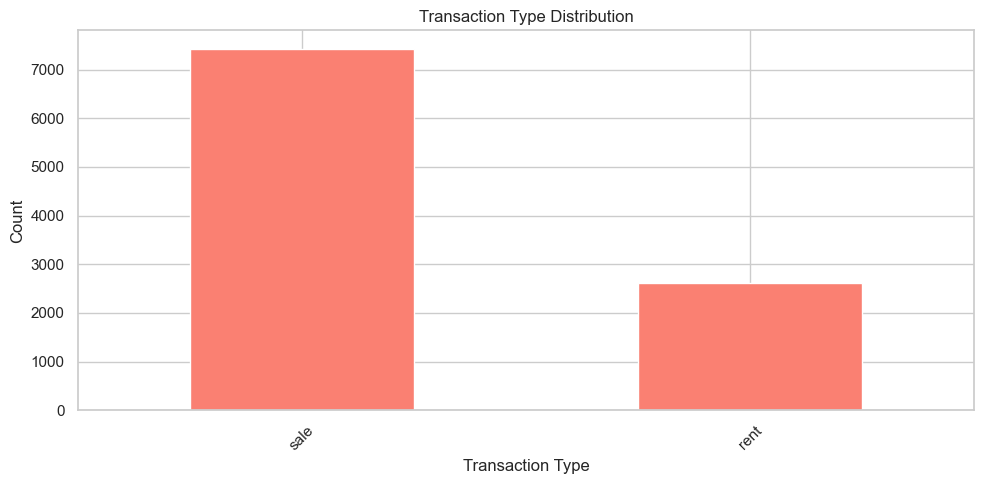

In [12]:
df['transaction_type'].fillna('Unknown').value_counts().plot(kind='bar', figsize=(10,5), color='salmon')
plt.title('Transaction Type Distribution')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

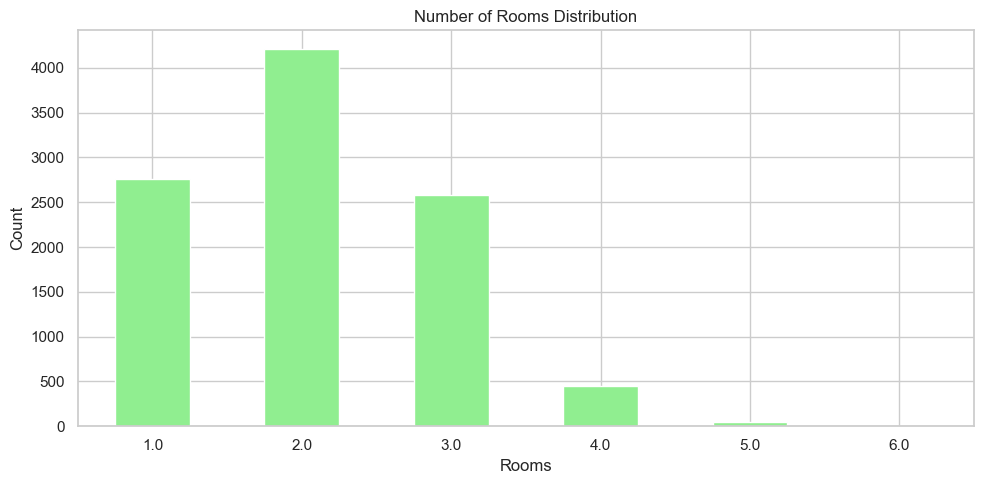

In [13]:
df['rooms'].fillna(0).value_counts().sort_index().plot(kind='bar', figsize=(10,5), color='lightgreen')
plt.title('Number of Rooms Distribution')
plt.xlabel('Rooms')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

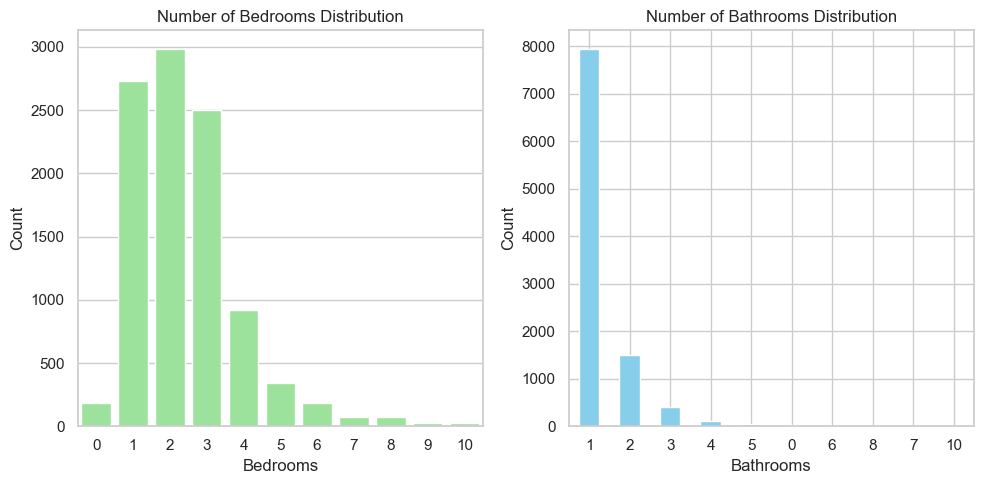

In [14]:
fig , axes = plt.subplots(1, 2, figsize=(15,5))
data = df.copy().loc[:, ['bedrooms', 'bathrooms']].fillna(0).astype(int)
sns.barplot(x=data['bedrooms'].value_counts().index, y=data['bedrooms'].value_counts().values, ax=axes[0], color='lightgreen')
axes[0].set_title('Number of Bedrooms Distribution')
axes[0].set_xlabel('Bedrooms')
axes[0].set_ylabel('Count')
data['bathrooms'].value_counts().plot(kind='bar', figsize=(10,5), color='skyblue', ax=axes[1])
axes[1].set_title('Number of Bathrooms Distribution')
axes[1].set_xlabel('Bathrooms')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

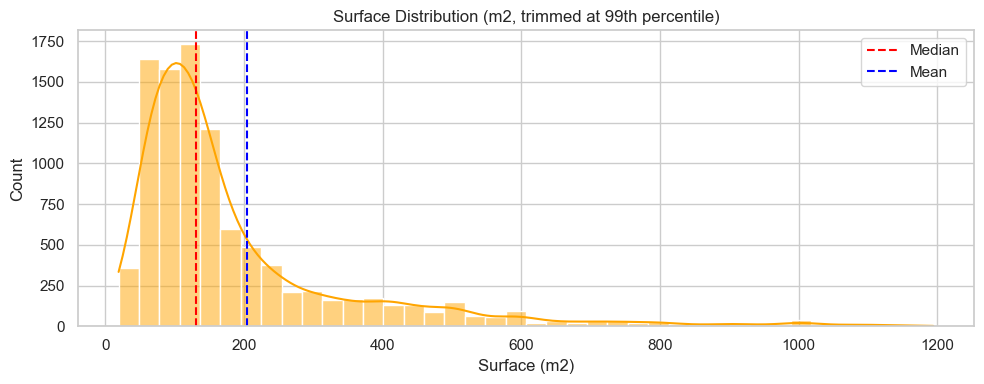

In [15]:
surface_sample = df['surface_m2'].dropna()
surface_sample = surface_sample[(surface_sample > 0) & (surface_sample < surface_sample.quantile(0.99))]
plt.figure(figsize=(10,4))
sns.histplot(surface_sample, bins=40, kde=True, color='orange')
plt.title('Surface Distribution (m2, trimmed at 99th percentile)')
plt.xlabel('Surface (m2)')
plt.tight_layout()
plt.axvline(df['surface_m2'].median(), color='red', linestyle='--', label='Median')
plt.axvline(df['surface_m2'].mean(), color='blue', linestyle='--', label='Mean')
plt.legend()
plt.show()

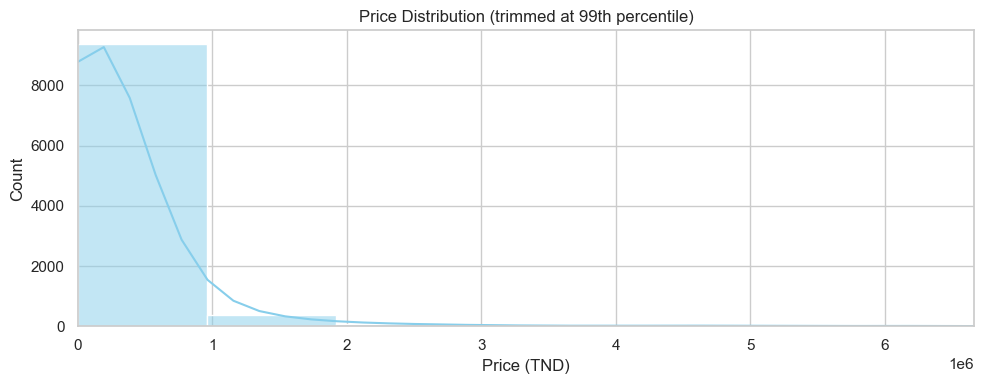

In [16]:
price_sample = df['price_tnd'].dropna()
price_sample = price_sample[(price_sample > 0) & (price_sample < price_sample.quantile(0.99))] # Remove outliers above 99th percentile
plt.figure(figsize=(10,4))
sns.histplot(price_sample, bins=40, kde=True, color='skyblue') 
plt.xlim(0, price_sample.quantile(0.99) * 1.1)
plt.title('Price Distribution (trimmed at 99th percentile)')
plt.xlabel('Price (TND)')
plt.tight_layout()
plt.show()

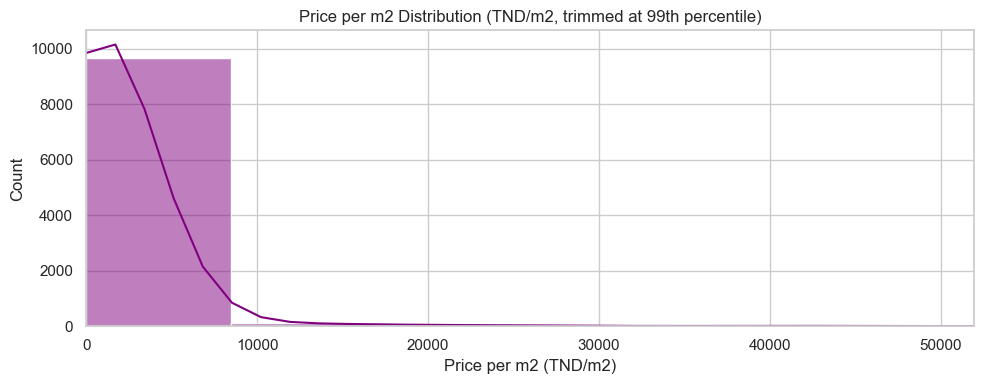

In [17]:
surface_sample = df['price_per_m2'].dropna()
surface_sample = surface_sample[(surface_sample > 0) & (surface_sample < surface_sample.quantile(0.99))]
plt.figure(figsize=(10,4))
sns.histplot(surface_sample, bins=40, kde=True, color='purple')
plt.xlim(0, surface_sample.quantile(0.99) * 1.1)
plt.title('Price per m2 Distribution (TND/m2, trimmed at 99th percentile)')
plt.xlabel('Price per m2 (TND/m2)')
plt.tight_layout()
plt.show()

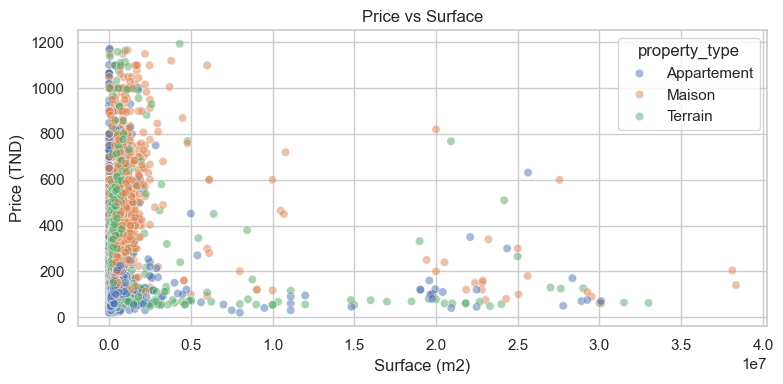

In [18]:
fig , ax = plt.subplots(figsize=(8,4))
data = df[(df['price_tnd'] > 0) & (df['price_tnd'] < df['price_tnd'].quantile(0.99)) & (df['surface_m2'] > 0) & (df['surface_m2'] < df['surface_m2'].quantile(0.99))]
sns.scatterplot(x='price_tnd', y='surface_m2', hue='property_type',data=data, alpha=0.5 ,ax=ax)
plt.title('Price vs Surface')
plt.xlabel('Surface (m2)')
plt.ylabel('Price (TND)')
plt.tight_layout()
plt.show()

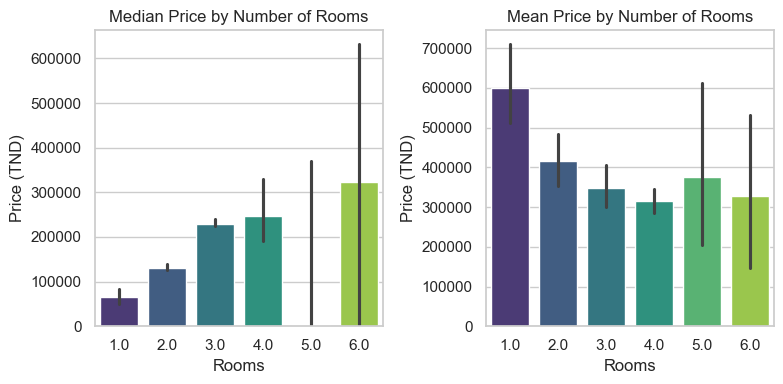

In [19]:
fig , axes = plt.subplots(1,2,figsize=(8,4))
sns.barplot(x='rooms', y='price_tnd', data=df[(df['price_tnd'] > 0) & (df['price_tnd'] < df['price_tnd'].quantile(0.99))], estimator='median', ax=axes[0], palette='viridis')
sns.barplot(x='rooms', y='price_tnd', data=df[(df['price_tnd'] > 0) & (df['price_tnd'] < df['price_tnd'].quantile(0.99))], estimator='mean', ax=axes[1], palette='viridis')
axes[0].set_title('Median Price by Number of Rooms')
axes[0].set_xlabel('Rooms')
axes[0].set_ylabel('Price (TND)')
axes[1].set_title('Mean Price by Number of Rooms')
axes[1].set_xlabel('Rooms')
axes[1].set_ylabel('Price (TND)')
plt.tight_layout()
plt.show()

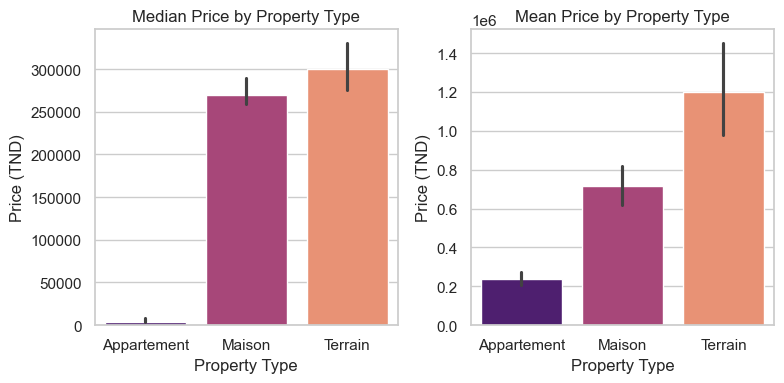

In [20]:
fig , axes = plt.subplots(1,2,figsize=(8,4))
sns.barplot(x='property_type', y='price_tnd', data=df[(df['price_tnd'] > 0) & (df['price_tnd'] < df['price_tnd'].quantile(0.99))], estimator='median', ax=axes[0], palette='magma')
sns.barplot(x='property_type', y='price_tnd', data=df[(df['price_tnd'] > 0) & (df['price_tnd'] < df['price_tnd'].quantile(0.99))], estimator='mean', ax=axes[1], palette='magma')
axes[0].set_title('Median Price by Property Type')
axes[0].set_xlabel('Property Type')
axes[0].set_ylabel('Price (TND)')
axes[1].set_title('Mean Price by Property Type')
axes[1].set_xlabel('Property Type')
axes[1].set_ylabel('Price (TND)')
plt.tight_layout()
plt.show()

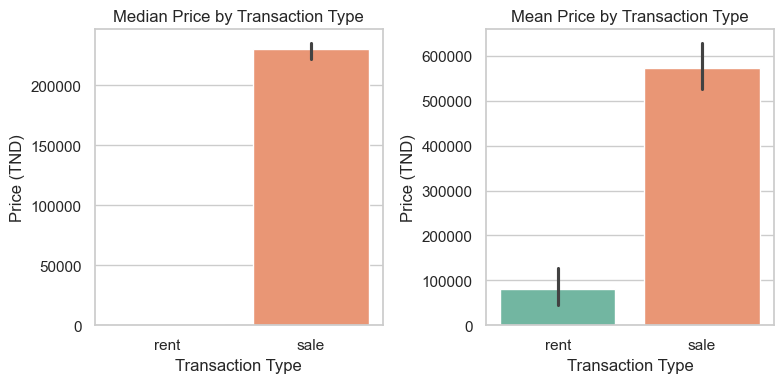

In [21]:
fig,axes = plt.subplots(1,2,figsize=(8,4))
sns.barplot(x='transaction_type', y='price_tnd', data=df[(df['price_tnd'] > 0) & (df['price_tnd'] < df['price_tnd'].quantile(0.99))], estimator='median', ax=axes[0], palette='Set2')
sns.barplot(x='transaction_type', y='price_tnd', data=df[(df['price_tnd'] > 0) & (df['price_tnd'] < df['price_tnd'].quantile(0.99))], estimator='mean', ax=axes[1], palette='Set2')
axes[0].set_title('Median Price by Transaction Type')
axes[0].set_xlabel('Transaction Type')
axes[0].set_ylabel('Price (TND)')
axes[1].set_title('Mean Price by Transaction Type')
axes[1].set_xlabel('Transaction Type')
axes[1].set_ylabel('Price (TND)')
plt.tight_layout()
plt.show()

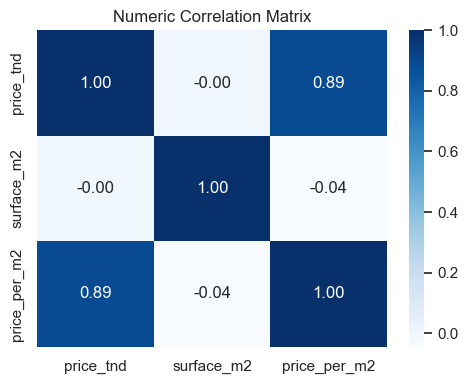

In [22]:
tmp = df[['price_tnd','surface_m2','price_per_m2']].dropna()
tmp = tmp[(tmp['price_tnd'] > 0) & (tmp['surface_m2'] > 0)]
corr = tmp.corr(numeric_only=True)
plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f')
plt.title('Numeric Correlation Matrix')
plt.tight_layout()
plt.show()

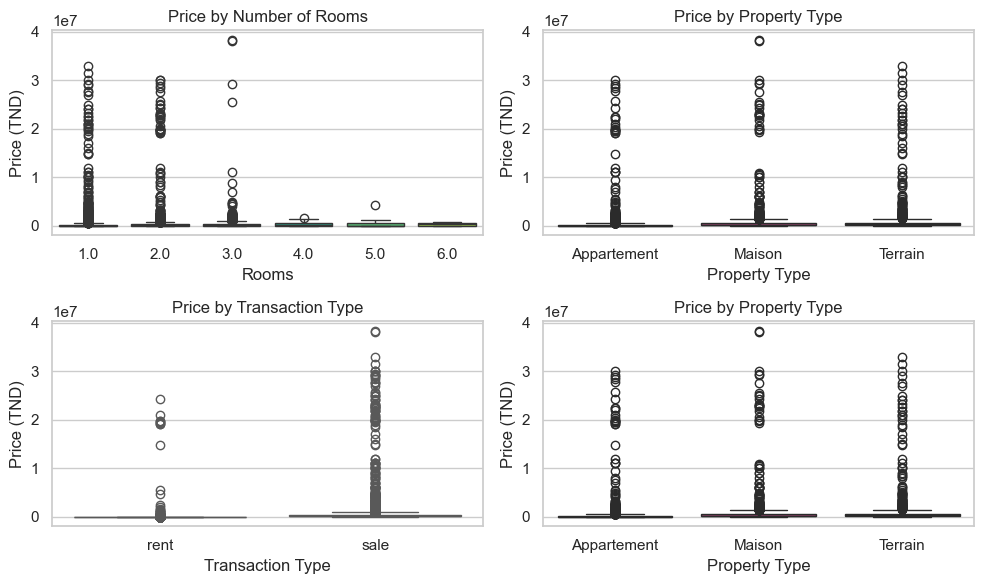

In [23]:
fig , axes = plt.subplots(2,2,figsize=(10,6))
sns.boxplot(x='property_type', y='price_tnd', data=df[(df['price_tnd'] > 0) & (df['price_tnd'] < df['price_tnd'].quantile(0.99))], ax=axes[0,1], palette='magma')
sns.boxplot(x='transaction_type', y='price_tnd', data=df[(df['price_tnd'] > 0) & (df['price_tnd'] < df['price_tnd'].quantile(0.99))], ax=axes[1,0], palette='Set2')
sns.boxplot(x='property_type', y='price_tnd', data=df[(df['price_tnd'] > 0) & (df['price_tnd'] < df['price_tnd'].quantile(0.99))], ax=axes[1,1], palette='magma')
sns.boxplot(x='rooms', y='price_tnd', data=df[(df['price_tnd'] > 0) & (df['price_tnd'] < df['price_tnd'].quantile(0.99))], ax=axes[0,0], palette='viridis')

axes[0,1].set_title('Price by Property Type')
axes[0,1].set_xlabel('Property Type')
axes[0,1].set_ylabel('Price (TND)')

axes[1,0].set_title('Price by Transaction Type')
axes[1,0].set_xlabel('Transaction Type')
axes[1,0].set_ylabel('Price (TND)')

axes[1,1].set_title('Price by Property Type')
axes[1,1].set_xlabel('Property Type')
axes[1,1].set_ylabel('Price (TND)')

axes[0,0].set_title('Price by Number of Rooms')
axes[0,0].set_xlabel('Rooms')
axes[0,0].set_ylabel('Price (TND)')

plt.tight_layout()
plt.show()

# Processing

In [24]:
import re
import numpy as np
import pandas as pd
from dataclasses import dataclass
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold
from sklearn.neighbors import BallTree
from sklearn.impute import KNNImputer
import category_encoders as ce


@dataclass
class PreprocessConfig:
    lat_col: str = "latitude"
    lon_col: str = "longitude"
    price_col: str = "price_tnd"
    size_col: str = "surface_m2"
    city_col: str = "city"
    governorate_col: str = "governorate"
    property_type_col: str = "property_type"
    transaction_col: str = "transaction_type"
    cat_cols: tuple = ("city", "governorate", "property_type", "transaction_type")
    n_geo_clusters: int = 20
    radius_km: float = 1.0
    n_splits: int = 5
    random_state: int = 42
    knn_neighbors: int = 5

In [25]:
class EstateProcessor:
    def __init__(self, cfg: PreprocessConfig = PreprocessConfig()):
        self.cfg = cfg
        self.kmeans = None
        self.tree = None
        self.train_price = None
        self.global_price = None
        self.local_avg_price_m2 = None
        self.final_te = None
        self.target_name = "target_log"
        self._scaler = None
        self._pca = None

    @staticmethod
    def _to_num(s):
        if pd.isna(s):
            return np.nan
        s = str(s).upper().replace("DT", "").replace("TND", "")
        s = re.sub(r"\s+", "", s).replace(",", ".")
        m = re.search(r"-?\d+(\.\d+)?", s)
        return float(m.group()) if m else np.nan

    def _clean(self, df: pd.DataFrame) -> pd.DataFrame:
        X = df.copy()

        cols_to_drop = ["record_id", "description", "location_raw"]
        X.drop(columns=[c for c in cols_to_drop if c in X.columns], inplace=True)

        numeric_cols = [
            self.cfg.price_col,
            self.cfg.size_col,
            "price_per_m2",
            "rooms",
            "bedrooms",
            "bathrooms",
            self.cfg.lat_col,
            self.cfg.lon_col,
        ]
        for c in numeric_cols:
            if c in X.columns:
                X[c] = X[c].map(self._to_num)

        for c in self.cfg.cat_cols:
            if c in X.columns:
                X[c] = X[c].astype(str).str.strip().str.lower().replace({"nan": np.nan, "": np.nan})

        if self.cfg.city_col in X.columns and self.cfg.governorate_col in X.columns:
            X["city_governorate"] = (
                X[self.cfg.city_col].fillna("unknown") + "__" + X[self.cfg.governorate_col].fillna("unknown")
            )

        return X

    def handle_missing(self, df: pd.DataFrame) -> pd.DataFrame:
        X = df.copy()

        num_cols = [c for c in X.select_dtypes(include=["number"]).columns if X[c].notna().any()]
        if num_cols:
            imputer = KNNImputer(n_neighbors=self.cfg.knn_neighbors, weights="distance")
            X[num_cols] = imputer.fit_transform(X[num_cols])

        for c in list(self.cfg.cat_cols) + ["city_governorate"]:
            if c in X.columns:
                mode_vals = X[c].mode(dropna=True)
                fill_val = mode_vals.iat[0] if not mode_vals.empty else "unknown"
                X[c] = X[c].fillna(fill_val)

        return X

    def outlier_treatment(self, df: pd.DataFrame) -> pd.DataFrame:
        X = df.copy()
        for c in [self.cfg.price_col, self.cfg.size_col]:
            if c in X.columns and X[c].notna().any():
                lo = X[c].quantile(0.01)
                hi = X[c].quantile(0.99)
                X[c] = X[c].clip(lower=lo, upper=hi)
        return X

    def make_target(self, df: pd.DataFrame) -> pd.Series:
        y = pd.to_numeric(df[self.cfg.price_col], errors="coerce")
        return np.log1p(y.clip(lower=0)) # type: ignore

    @staticmethod
    def invert_target(pred_log: np.ndarray) -> np.ndarray:
        return np.expm1(pred_log)

    def scale_features(self, X: pd.DataFrame, is_train: bool = True) -> pd.DataFrame:
        out = X.copy()
        num_cols = out.select_dtypes(include=["number"]).columns.tolist()
        if not num_cols:
            return out

        from sklearn.preprocessing import StandardScaler

        if is_train:
            self._scaler = StandardScaler()
            out[num_cols] = self._scaler.fit_transform(out[num_cols])
        else:
            if self._scaler is None:
                return out
            out[num_cols] = self._scaler.transform(out[num_cols])
        return out

    def dimension_reduction(self, X: pd.DataFrame, is_train: bool = True, n_components: int = 20) -> pd.DataFrame:
        out = X.copy()
        num_cols = out.select_dtypes(include=["number"]).columns.tolist()
        if len(num_cols) <= 3:
            return out

        n_comp = min(n_components, max(2, len(num_cols) - 1), len(out) - 1 if len(out) > 2 else 2)
        if n_comp < 2:
            return out

        from sklearn.decomposition import PCA

        if is_train:
            self._pca = PCA(n_components=n_comp, random_state=self.cfg.random_state)
            reduced = self._pca.fit_transform(out[num_cols])
        else:
            if self._pca is None:
                return out
            reduced = self._pca.transform(out[num_cols])

        reduced_df = pd.DataFrame(
            reduced,
            columns=[f"pca_{i+1}" for i in range(reduced.shape[1])],
            index=out.index,
        )
        out = out.drop(columns=num_cols)
        out = pd.concat([out, reduced_df], axis=1)
        return out

    def _fit_geo(self, X: pd.DataFrame):
        if self.cfg.lat_col not in X.columns or self.cfg.lon_col not in X.columns:
            return

        coords = X[[self.cfg.lat_col, self.cfg.lon_col]].apply(pd.to_numeric, errors="coerce")
        valid = coords.notna().all(axis=1)
        coords_valid = coords[valid]
        if len(coords_valid) == 0:
            return

        self.kmeans = KMeans(
            n_clusters=min(self.cfg.n_geo_clusters, len(coords_valid)),
            random_state=self.cfg.random_state,
            n_init=10,
        ).fit(coords_valid.values)

        self.tree = BallTree(np.radians(coords_valid.values), metric="haversine")

    def _spatial_features(self, X: pd.DataFrame, y_log: pd.Series | None, is_train: bool) -> pd.DataFrame:
        out = X.copy()
        out["geo_cluster_id"] = np.nan
        out["avg_price_1km_radius"] = np.nan
        out["listings_density_in_area"] = np.nan

        if self.kmeans is None or self.tree is None:
            return out
        if self.cfg.lat_col not in out.columns or self.cfg.lon_col not in out.columns:
            return out

        coords = out[[self.cfg.lat_col, self.cfg.lon_col]].apply(pd.to_numeric, errors="coerce")
        valid = coords.notna().all(axis=1)
        if valid.sum() == 0:
            return out

        vals = coords[valid].values
        out.loc[valid, "geo_cluster_id"] = self.kmeans.predict(vals)
        query_rad = np.radians(vals)
        r = self.cfg.radius_km / 6371.0
        neighbors = self.tree.query_radius(query_rad, r=r)

        if is_train and y_log is not None:
            self.train_price = np.expm1(y_log.values)
            self.global_price = float(np.nanmean(self.train_price))

        if self.train_price is None:
            return out

        avg_prices, densities = [], []
        area = np.pi * (self.cfg.radius_km ** 2)

        for i, idx in enumerate(neighbors):
            idx = idx.tolist()
            if is_train:
                idx = [j for j in idx if j != i]
            if len(idx) == 0:
                avg_prices.append(self.global_price)
                densities.append(0.0)
            else:
                avg_prices.append(float(np.nanmean(self.train_price[idx])))
                densities.append(len(idx) / area)

        out.loc[valid, "avg_price_1km_radius"] = avg_prices
        out.loc[valid, "listings_density_in_area"] = densities

        if self.cfg.city_col in out.columns and self.cfg.governorate_col in out.columns:
            out["city_governorate"] = (
                out[self.cfg.city_col].fillna("unknown") + "__" + out[self.cfg.governorate_col].fillna("unknown")
            )
        return out

    def _interaction_features(self, X: pd.DataFrame, y_log: pd.Series | None, is_train: bool) -> pd.DataFrame:
        out = X.copy()

        local_key = "city_governorate" if "city_governorate" in out.columns else self.cfg.city_col
        ppm2 = out[self.cfg.price_col] / out[self.cfg.size_col].replace({0: np.nan})

        if is_train and y_log is not None and local_key in out.columns:
            self.local_avg_price_m2 = (
                pd.DataFrame({"k": out[local_key], "ppm2": ppm2})
                .groupby("k", dropna=True)["ppm2"]
                .median()
                .to_dict()
            )

        out["local_avg_price_m2"] = (
            out[local_key].map(self.local_avg_price_m2 if self.local_avg_price_m2 else {})
            if local_key in out.columns
            else np.nan
        )
        out["size_x_local_price"] = out[self.cfg.size_col] * out["local_avg_price_m2"]
        return out

    def _kfold_target_encode_train(self, X: pd.DataFrame, y_log: pd.Series) -> pd.DataFrame:
        X_enc = X.copy()
        kf = KFold(n_splits=self.cfg.n_splits, shuffle=True, random_state=self.cfg.random_state)

        usable_cat_cols = [c for c in list(self.cfg.cat_cols) + ["city_governorate"] if c in X_enc.columns]
        for c in usable_cat_cols:
            X_enc[f"{c}_te"] = np.nan

        for tr_idx, va_idx in kf.split(X_enc):
            tr_x, va_x = X_enc.iloc[tr_idx], X_enc.iloc[va_idx]
            tr_y = y_log.iloc[tr_idx]
            te = ce.TargetEncoder(cols=usable_cat_cols, smoothing=20)
            te.fit(tr_x[usable_cat_cols], tr_y)
            va_te = te.transform(va_x[usable_cat_cols])
            for c in usable_cat_cols:
                X_enc.loc[X_enc.index[va_idx], f"{c}_te"] = va_te[c].values

        self.final_te = ce.TargetEncoder(cols=usable_cat_cols, smoothing=20)
        self.final_te.fit(X_enc[usable_cat_cols], y_log)
        return X_enc

    def _apply_final_te(self, X: pd.DataFrame) -> pd.DataFrame:
        if self.final_te is None:
            return X

        usable_cat_cols = [c for c in list(self.cfg.cat_cols) + ["city_governorate"] if c in X.columns]
        te_vals = self.final_te.transform(X[usable_cat_cols])
        out = X.copy()
        for c in usable_cat_cols:
            out[f"{c}_te"] = te_vals[c].values
        return out

    def encode_features(
        self,
        X: pd.DataFrame,
        y_log: pd.Series | None = None,
        is_train: bool = True,
        method: str = "target",
    ) -> pd.DataFrame:
        out = X.copy()
        usable_cat_cols = [c for c in list(self.cfg.cat_cols) + ["city_governorate"] if c in out.columns]
        if not usable_cat_cols:
            return out

        method = method.lower()

        if method == "target":
            if is_train:
                if y_log is None:
                    raise ValueError("y_log is required for target encoding in training mode.")
                out = self._kfold_target_encode_train(out, y_log)
            else:
                out = self._apply_final_te(out)

            out = out.drop(columns=usable_cat_cols, errors="ignore")
            return out

        if method == "onehot":
            out = pd.get_dummies(out, columns=usable_cat_cols, dummy_na=True)
            return out

        raise ValueError(f"Unknown encoding method: {method}")

    def fit_transform_train(self, df: pd.DataFrame, model_type: str = "lgbm"):
        X = self._clean(df)
        X = self.handle_missing(X)
        X = self.outlier_treatment(X)

        X = X[pd.to_numeric(X[self.cfg.price_col], errors="coerce").notna()].copy()
        X = X[X[self.cfg.price_col] > 0].copy()

        y_log = self.make_target(X)

        self._fit_geo(X)
        X = self._spatial_features(X, y_log=y_log, is_train=True)
        X = self._interaction_features(X, y_log=y_log, is_train=True)

        if model_type.lower() == "catboost":
            return X, y_log, [c for c in list(self.cfg.cat_cols) + ["city_governorate"] if c in X.columns]

        X = self.encode_features(X, y_log=y_log, is_train=True, method="target")

        if model_type.lower() in {"ridge", "lasso", "elasticnet", "svm", "knn"}:
            X = self.scale_features(X, is_train=True)

        if model_type.lower() in {"ridge", "lasso", "elasticnet", "svm"}:
            X = self.dimension_reduction(X, is_train=True, n_components=20)

        return X, y_log, []

    def transform_infer(self, df: pd.DataFrame, model_type: str = "lgbm"):
        X = self._clean(df)
        X = self.handle_missing(X)
        X = self.outlier_treatment(X)
        X = self._spatial_features(X, y_log=None, is_train=False)
        X = self._interaction_features(X, y_log=None, is_train=False)

        if model_type.lower() == "catboost":
            return X, [c for c in list(self.cfg.cat_cols) + ["city_governorate"] if c in X.columns]

        X = self.encode_features(X, y_log=None, is_train=False, method="target")

        if model_type.lower() in {"ridge", "lasso", "elasticnet", "svm", "knn"}:
            X = self.scale_features(X, is_train=False)

        if model_type.lower() in {"ridge", "lasso", "elasticnet", "svm"}:
            X = self.dimension_reduction(X, is_train=False, n_components=20)

        return X, []


In [26]:
# Split raw dataframe
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [27]:
# Run your class preprocessing pipeline
pp = EstateProcessor()
X_train , y_train_log, cat_cols = pp.fit_transform_train(train_df, model_type="catboost")
X_test, _ = pp.transform_infer(test_df, model_type="catboost")

#Print Shapes and categorical columns for verification
print("Training features shape:", X_train.shape)
print("Training target shape:", y_train_log.shape)
print("Categorical columns for CatBoost:", cat_cols)

Training features shape: (8044, 18)
Training target shape: (8044,)
Categorical columns for CatBoost: ['city', 'governorate', 'property_type', 'transaction_type', 'city_governorate']


In [28]:
# Build y_test_log from test_df (aligned to X_test index)
y_test_log = pp.make_target(pp._clean(test_df)).loc[X_test.index]
print("Test target shape:", y_test_log.shape)

Test target shape: (2011,)


# Training

In [29]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error , r2_score
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from catboost import CatBoostRegressor

In [30]:
TYPE_COL = "property_type"
results = []
best_models_by_type = {}

for ptype in sorted(X_train[TYPE_COL].dropna().astype(str).str.title().unique()):
    tr_mask = X_train[TYPE_COL].astype(str).str.title() == ptype
    te_mask = X_test[TYPE_COL].astype(str).str.title() == ptype

    Xtr = X_train.loc[tr_mask].copy()
    ytr = y_train_log.loc[tr_mask].copy()
    Xte = X_test.loc[te_mask].copy()
    yte = y_test_log.loc[te_mask].copy()

    if len(Xtr) < 100 or len(Xte) == 0:
        continue

    model = CatBoostRegressor(
        depth=8,
        learning_rate=0.05,
        iterations=600,
        loss_function="RMSE",
        eval_metric="R2",
        random_state=42,
        verbose=False
    )

    model.fit(
        Xtr,
        ytr,
        cat_features=[c for c in (cat_cols or []) if c in Xtr.columns]
    )

    pred_te_log = model.predict(Xte)
    pred_tr_log = model.predict(Xtr)

    yte_price = np.expm1(yte.values)
    pred_te_price = np.expm1(pred_te_log)
    ytr_price = np.expm1(ytr.values)
    pred_tr_price = np.expm1(pred_tr_log)

    test_r2 = r2_score(yte_price, pred_te_price)
    test_rmse = np.sqrt(mean_squared_error(yte_price, pred_te_price))
    train_r2 = r2_score(ytr_price, pred_tr_price)

    results.append({
        "property_type": ptype,
        "model": "catboost",
        "train_rows": len(Xtr),
        "test_rows": len(Xte),
        "train_r2": train_r2,
        "test_r2": test_r2,
        "test_rmse": test_rmse,
    })

    best_models_by_type[ptype] = {"model_name": "catboost", "estimator": model}

results_df = pd.DataFrame(results).sort_values("test_rmse")
display(results_df)


,property_type,model,train_rows,test_rows,train_r2,test_r2,test_rmse
0,Appartement,catboost,5312,1353,0.997816,0.459911,4.497086e+06
1,Maison,catboost,1915,496,0.998482,0.454741,9.768768e+06
2,Terrain,catboost,817,162,0.996910,0.340834,2.100817e+07


In [34]:
# Config
TARGET_COL = "price_tnd"
TYPE_COL = "property_type"
RANDOM_STATE = 42
CV_SPLITS = 3
MIN_ROWS_PER_TYPE = 120
MODEL_TYPE = "catboost"  # uses EstateProcessor catboost branch

# Speed knobs
FAST_MODE = True
FAST_MODELS = ("catboost", "et", "ridge")
FULL_MODELS = ("catboost", "rf", "et", "gbr", "ridge")
FAST_N_ITER = 6
FULL_N_ITER = 12

cat_cols = cat_cols or []
cat_cols_test = _ or []

In [ ]:
# Metrics helpers
def eval_price(y_true_log, y_pred_log):
    y_true = np.expm1(np.asarray(y_true_log))
    y_pred = np.expm1(np.asarray(y_pred_log))
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    medae = float(median_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    return rmse, mae, medae, r2


def diagnose_fit(train_r2: float, test_r2: float, gap_rmse: float) -> str:
    if train_r2 < 0.3 and test_r2 < 0.3:
        return "underfitting"
    if (train_r2 - test_r2) > 0.15 and gap_rmse > 0:
        return "overfitting"
    return "balanced"


def _prepare_non_cat_features(Xtr: pd.DataFrame, Xte: pd.DataFrame):
    Xtr_m = pd.get_dummies(Xtr, dummy_na=True)
    Xte_m = pd.get_dummies(Xte, dummy_na=True).reindex(columns=Xtr_m.columns, fill_value=0)

    Xtr_m = Xtr_m.replace([np.inf, -np.inf], np.nan)
    Xte_m = Xte_m.replace([np.inf, -np.inf], np.nan)

    fill_vals = Xtr_m.median(numeric_only=True)
    Xtr_m = Xtr_m.fillna(fill_vals).fillna(0.0)
    Xte_m = Xte_m.fillna(fill_vals).fillna(0.0)
    return Xtr_m, Xte_m


def get_model_search_spaces(*, fast_mode: bool = FAST_MODE, model_names: tuple[str, ...] | None = None):
    from sklearn.model_selection import RandomizedSearchCV
    from scipy.stats import randint, uniform, loguniform

    cv = KFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    n_iter = FAST_N_ITER if fast_mode else FULL_N_ITER
    chosen = set(model_names or (FAST_MODELS if fast_mode else FULL_MODELS))

    searches = {}

    if "catboost" in chosen:
        searches["catboost"] = RandomizedSearchCV(
            estimator=CatBoostRegressor(random_state=RANDOM_STATE, verbose=False),#type: ignore
            param_distributions={
                "depth": randint(5, 9),
                "learning_rate": loguniform(0.02, 0.12),
                "iterations": randint(220, 520),
                "l2_leaf_reg": randint(2, 10),
            },
            n_iter=n_iter,
            scoring="neg_root_mean_squared_error",
            cv=cv,
            n_jobs=-1,
            refit=True,
            verbose=0,
            random_state=RANDOM_STATE,
        )

    if "rf" in chosen:
        searches["rf"] = RandomizedSearchCV(
            estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
            param_distributions={
                "n_estimators": randint(180, 520),
                "max_depth": [None, 10, 16, 24],
                "min_samples_leaf": randint(1, 5),
                "max_features": ["sqrt", "log2", 0.8],
            },
            n_iter=n_iter,
            scoring="neg_root_mean_squared_error",
            cv=cv,
            n_jobs=-1,
            refit=True,
            verbose=0,
            random_state=RANDOM_STATE,
        )

    if "et" in chosen:
        searches["et"] = RandomizedSearchCV(
            estimator=ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1),
            param_distributions={
                "n_estimators": randint(180, 520),
                "max_depth": [None, 10, 16, 24],
                "min_samples_leaf": randint(1, 5),
                "max_features": ["sqrt", "log2", 0.8],
            },
            n_iter=n_iter,
            scoring="neg_root_mean_squared_error",
            cv=cv,
            n_jobs=-1,
            refit=True,
            verbose=0,
            random_state=RANDOM_STATE,
        )

    if "gbr" in chosen:
        searches["gbr"] = RandomizedSearchCV(
            estimator=GradientBoostingRegressor(random_state=RANDOM_STATE),
            param_distributions={
                "n_estimators": randint(120, 380),
                "learning_rate": loguniform(0.03, 0.2),
                "max_depth": randint(2, 5),
                "subsample": uniform(0.7, 0.3),
            },
            n_iter=n_iter,
            scoring="neg_root_mean_squared_error",
            cv=cv,
            n_jobs=-1,
            refit=True,
            verbose=0,
            random_state=RANDOM_STATE,
        )

    if "ridge" in chosen:
        searches["ridge"] = GridSearchCV(
            estimator=Ridge(random_state=RANDOM_STATE),
            param_grid={"alpha": [0.1, 1.0, 10.0, 30.0]},
            scoring="neg_root_mean_squared_error",
            cv=cv,
            n_jobs=-1,
            refit=True,
            verbose=0,
        )

    return searches


def _fit_and_score_model(model_name, gs, Xtr, ytr, Xte, yte, non_cat_cache=None):
    if model_name == "catboost":
        gs.fit(Xtr, ytr, cat_features=[c for c in cat_cols if c in Xtr.columns])
        pred_te_log = gs.best_estimator_.predict(Xte)
        pred_tr_log = gs.best_estimator_.predict(Xtr)
    else:
        Xtr_m, Xte_m = non_cat_cache if non_cat_cache is not None else _prepare_non_cat_features(Xtr, Xte)
        gs.fit(Xtr_m, ytr)
        pred_te_log = gs.predict(Xte_m)
        pred_tr_log = gs.predict(Xtr_m)

    te_rmse, te_mae, te_medae, te_r2 = eval_price(yte, pred_te_log)
    tr_rmse, tr_mae, tr_medae, tr_r2 = eval_price(ytr, pred_tr_log)

    row = {
        "cv_rmse_log": float(-gs.best_score_),
        "test_rmse": te_rmse,
        "test_mae": te_mae,
        "test_medae": te_medae,
        "test_r2": te_r2,
        "train_rmse": tr_rmse,
        "train_r2": tr_r2,
        "overfit_gap_rmse": te_rmse - tr_rmse,
        "fit_status": diagnose_fit(tr_r2, te_r2, te_rmse - tr_rmse),
        "best_params": gs.best_params_,
    }
    return row, gs.best_estimator_


def train_by_property_type(
    X_train, y_train_log, X_test, y_test_log, type_col=TYPE_COL, *, fast_mode: bool = FAST_MODE, model_names=None
):
    results = []
    best_models_by_type = {}

    for ptype in sorted(X_train[type_col].dropna().astype(str).str.title().unique()):
        tr_mask = X_train[type_col].astype(str).str.title() == ptype
        te_mask = X_test[type_col].astype(str).str.title() == ptype

        Xtr = X_train.loc[tr_mask].copy()
        ytr = y_train_log.loc[tr_mask].copy()
        Xte = X_test.loc[te_mask].copy()
        yte = y_test_log.loc[te_mask].copy()

        if len(Xtr) < MIN_ROWS_PER_TYPE or len(Xte) == 0:
            print(f"[SKIP] {ptype}: train={len(Xtr)}, test={len(Xte)}")
            continue

        searches = get_model_search_spaces(fast_mode=fast_mode, model_names=model_names)
        non_cat_cache = _prepare_non_cat_features(Xtr, Xte)

        best_rmse = np.inf
        best_name = None
        best_estimator = None
        best_row = None

        for model_name, gs in searches.items():
            row_metrics, estimator = _fit_and_score_model(
                model_name, gs, Xtr, ytr, Xte, yte, non_cat_cache=non_cat_cache
            )
            row = {
                "scope": "by_type",
                "property_type": ptype,
                "model": model_name,
                "rows_train": int(len(Xtr)),
                "rows_test": int(len(Xte)),
                **row_metrics,
            }
            results.append(row)

            if row["test_rmse"] < best_rmse:
                best_rmse = row["test_rmse"]
                best_name = model_name
                best_estimator = estimator
                best_row = row

        best_models_by_type[ptype] = {"model_name": best_name, "estimator": best_estimator, "metrics": best_row}

    return pd.DataFrame(results), best_models_by_type


def train_global(
    X_train, y_train_log, X_test, y_test_log, *, fast_mode: bool = FAST_MODE, model_names=None
):
    searches = get_model_search_spaces(fast_mode=fast_mode, model_names=model_names)
    rows = []
    best_rmse = np.inf
    best_model_name = None
    best_estimator = None
    best_row = None

    non_cat_cache = _prepare_non_cat_features(X_train, X_test)

    for model_name, gs in searches.items():
        row_metrics, estimator = _fit_and_score_model(
            model_name, gs, X_train, y_train_log, X_test, y_test_log, non_cat_cache=non_cat_cache
        )

        row = {
            "scope": "global",
            "property_type": "ALL",
            "model": model_name,
            "rows_train": int(len(X_train)),
            "rows_test": int(len(X_test)),
            **row_metrics,
        }
        rows.append(row)

        if row["test_rmse"] < best_rmse:
            best_rmse = row["test_rmse"]
            best_model_name = model_name
            best_estimator = estimator
            best_row = row

    return pd.DataFrame(rows), {"model_name": best_model_name, "estimator": best_estimator, "metrics": best_row}

In [36]:
# Execute training by property type 
results_by_type_df, best_models_by_type = train_by_property_type(
    X_train=X_train,
    y_train_log=y_train_log,
    X_test=X_test,
    y_test_log=y_test_log,
    fast_mode=True,
    model_names=FAST_MODELS,
)

# Execute global training (fast profile)
results_global_df, best_global_model = train_global(
    X_train=X_train,
    y_train_log=y_train_log,
    X_test=X_test,
    y_test_log=y_test_log,
    fast_mode=True,
    model_names=FAST_MODELS,
)

In [37]:
# Display results
all_results = pd.concat([results_by_type_df, results_global_df], ignore_index=True).sort_values(
    ["scope", "property_type", "test_rmse"]
)

display(all_results[[
    "scope", "property_type", "model",
    "test_rmse", "test_mae", "test_medae", "test_r2",
    "train_r2", "overfit_gap_rmse", "fit_status"
]].head(50))

,scope,property_type,model,test_rmse,test_mae,test_medae,test_r2,train_r2,overfit_gap_rmse,fit_status
0,by_type,Appartement,catboost,4.178883e+06,2.391093e+05,251.541238,0.533638,0.991832,3.965103e+06,overfitting
1,by_type,Appartement,et,4.548140e+06,2.980523e+05,5673.015669,0.447579,0.979473,4.209238e+06,overfitting
2,by_type,Appartement,ridge,2.144105e+09,9.562234e+07,36657.747815,-122769.679242,-51157.902615,1.609089e+09,underfitting
4,by_type,Maison,et,9.433833e+06,1.252001e+06,23789.599117,0.491489,0.997177,9.222559e+06,overfitting
3,by_type,Maison,catboost,9.457270e+06,1.206604e+06,7412.182290,0.488960,0.996345,9.216901e+06,overfitting
5,by_type,Maison,ridge,1.325023e+08,1.466550e+07,135602.518111,-99.316038,-34.367707,1.088561e+08,underfitting
7,by_type,Terrain,et,2.055969e+07,3.520279e+06,10653.350582,0.368677,0.999552,2.039709e+07,overfitting
6,by_type,Terrain,catboost,2.085868e+07,3.544241e+06,7474.921656,0.350181,0.996297,2.039101e+07,overfitting
8,by_type,Terrain,ridge,6.988256e+07,1.231112e+07,133603.805510,-6.293840,-0.469636,6.056591e+07,underfitting
9,global,ALL,catboost,8.103448e+06,7.103962e+05,1496.958672,0.473237,0.995208,7.844552e+06,overfitting


In [ ]:
# Save artifacts
Path("artifacts").mkdir(parents=True, exist_ok=True)
all_results.to_csv("../artifacts/models/training_estateprocessor_results.csv", index=False)

# save best models
import joblib
model_dir = Path("../artifacts/models/models_estateprocessor")
model_dir.mkdir(parents=True, exist_ok=True)

manifest = []

for ptype, info in best_models_by_type.items():
    fname = f"bytype__{ptype.lower()}__{info['model_name']}.joblib".replace(" ", "_")
    fpath = model_dir / fname
    joblib.dump(info["estimator"], fpath)
    manifest.append({
        "scope": "by_type",
        "property_type": ptype,
        "model_name": info["model_name"],
        "path": str(fpath),
        "metrics": info["metrics"],
    })

fname = f"global__{best_global_model['model_name']}.joblib"
fpath = model_dir / fname
joblib.dump(best_global_model["estimator"], fpath)
manifest.append({
    "scope": "global",
    "property_type": "ALL",
    "model_name": best_global_model["model_name"],
    "path": str(fpath),
    "metrics": best_global_model["metrics"],
})

Path("../artifacts/models/training_estateprocessor_manifest.json").write_text(
    json.dumps(manifest, indent=2, default=str),
    encoding="utf-8"
)

print("Saved models and manifest to artifacts/ directory")

Saved:
- artifacts/training_estateprocessor_results.csv
- artifacts/training_estateprocessor_manifest.json
- artifacts\models_estateprocessor
